In [ ]:
!pip install streamlit pyngrok scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


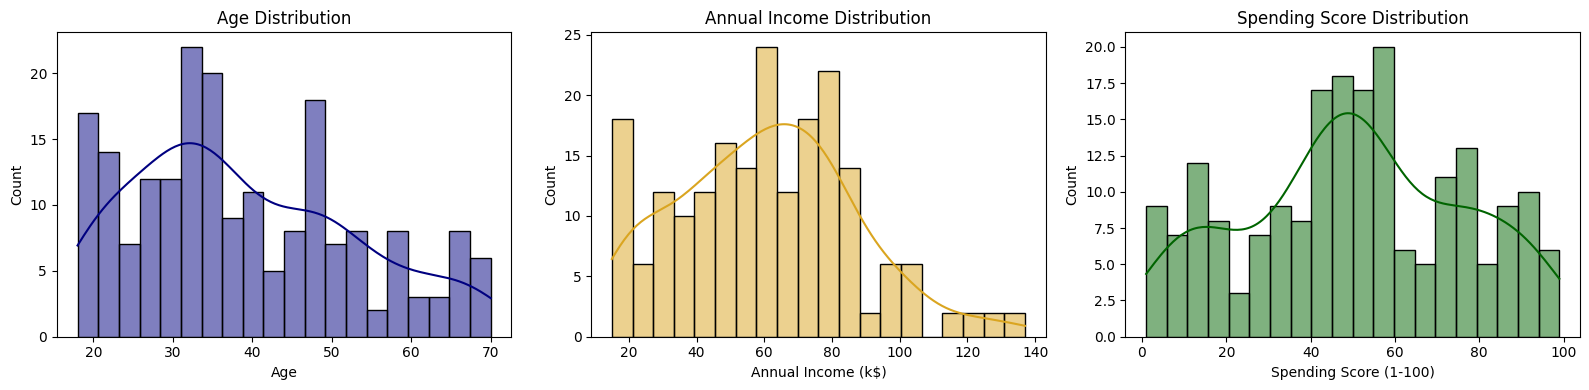

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='navy')
axes[0].set_title('Age Distribution')

# Income distribution
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='goldenrod')
axes[1].set_title('Annual Income Distribution')

# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='darkgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

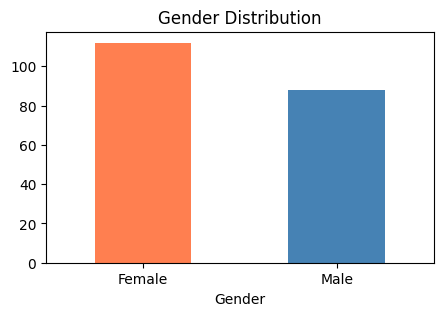

In [ ]:
# Gender breakdown
df['Gender'].value_counts().plot(kind='bar', color=['coral','steelblue'], figsize=(5,3))
plt.title('Gender Distribution')
plt.xticks(rotation=0)
plt.show()

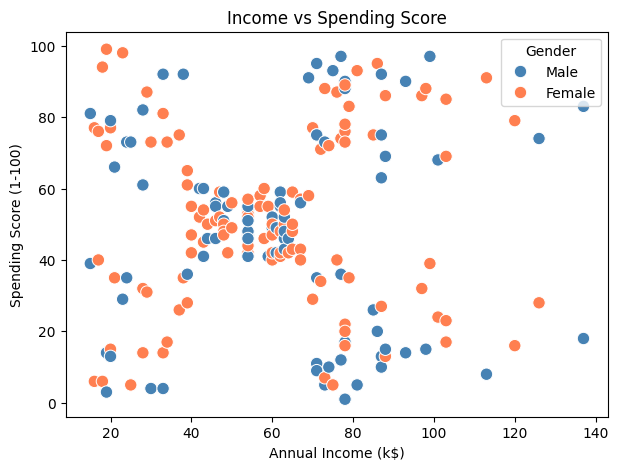

In [ ]:
# Spending Score vs Annual Income — coloured by Gender
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', palette={'Male':'steelblue','Female':'coral'}, s=80)
plt.title('Income vs Spending Score')
plt.show()

In [ ]:
df['Gender_encoded'] = (df['Gender'] == 'Male').astype(int)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features ready. Shape:", X_scaled.shape)

Features ready. Shape: (200, 4)


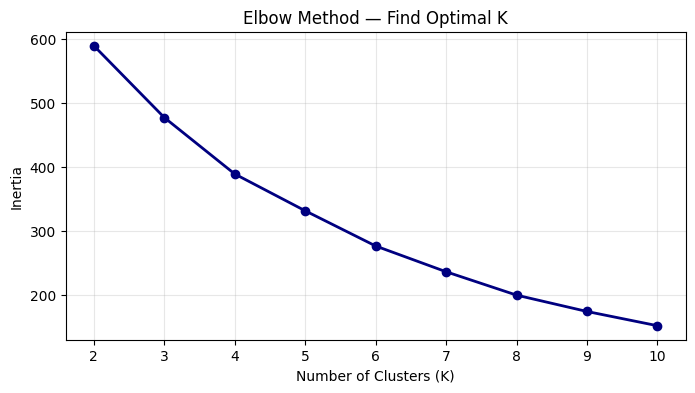

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='navy', linewidth=2)
plt.title('Elbow Method — Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Use k=5 (works well for this dataset)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

# Label each segment meaningfully
segment_labels = {
    0: 'Mid Income, Mid Spenders',
    1: 'High Income, Low Spenders',
    2: 'Low Income, Low Spenders',
    3: 'Low Income, High Spenders',
    4: 'High Income, High Spenders'
}

segment_descriptions = {
    0: "Average income and spending. Recommend versatile, mid-range everyday fashion.",
    1: "Earn well but spend cautiously. Recommend premium quality, timeless classics.",
    2: "Budget-conscious shoppers. Recommend affordable basics and sale items.",
    3: "Low income but love to splurge. Recommend trendy, aspirational pieces.",
    4: "Top-tier customers. Recommend exclusive luxury items and new arrivals."
}

segment_products = {
    0: ["Classic Trench Coat", "Slim Fit Chinos", "Leather Belt", "Cotton Polo Shirt", "Canvas Sneakers"],
    1: ["Cashmere Sweater", "Tailored Blazer", "Leather Oxford Shoes", "Merino Wool Scarf", "Premium Watch Strap"],
    2: ["Basic T-Shirt Pack", "Denim Jeans", "Canvas Tote Bag", "Casual Hoodie", "Ankle Socks Set"],
    3: ["Sequin Evening Dress", "Statement Handbag", "Block Heel Boots", "Printed Silk Scarf", "Chunky Gold Necklace"],
    4: ["Burberry Heritage Trench", "Monogram Leather Bag", "Limited Edition Sneakers", "Designer Sunglasses", "Embroidered Silk Blouse"]
}

df['Segment_Name'] = df['Segment'].map(segment_labels)
print(df['Segment_Name'].value_counts())

Segment_Name
Low Income, High Spenders     54
Low Income, Low Spenders      43
Mid Income, Mid Spenders      39
High Income, High Spenders    35
High Income, Low Spenders     29
Name: count, dtype: int64


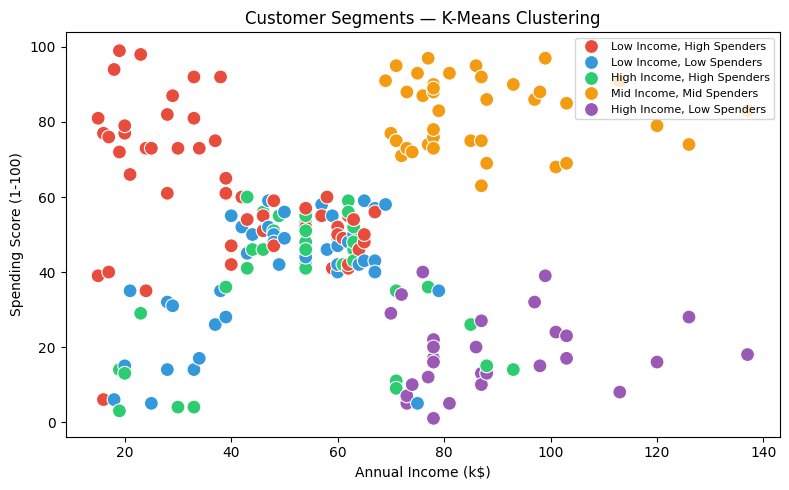

In [ ]:
plt.figure(figsize=(8, 5))
palette = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment_Name', palette=palette, s=100)
plt.title('Customer Segments — K-Means Clustering')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('segment_labels.pkl', 'wb') as f:
    pickle.dump(segment_labels, f)

with open('segment_descriptions.pkl', 'wb') as f:
    pickle.dump(segment_descriptions, f)

with open('segment_products.pkl', 'wb') as f:
    pickle.dump(segment_products, f)

print("✅ All models saved successfully!")

✅ All models saved successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np
import heapq
import requests

# ── Load Models ───────────────────────────────────────────────────
with open('kmeans_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('segment_labels.pkl', 'rb') as f:
    segment_labels = pickle.load(f)
with open('segment_descriptions.pkl', 'rb') as f:
    segment_descriptions = pickle.load(f)

segment_icons = {0: '🛍️', 1: '💼', 2: '💰', 3: '✨', 4: '💎'}

PEXELS_API_KEY = "YOURAPI KEY"

# ── Product Catalog ───────────────────────────────────────────────
PRODUCT_CATALOG = {
    0: [
        {"name": "Classic Trench Coat",    "price_tier": 2, "popularity": 85},
        {"name": "Slim Fit Chinos",         "price_tier": 2, "popularity": 78},
        {"name": "Leather Belt",            "price_tier": 2, "popularity": 72},
        {"name": "Cotton Polo Shirt",       "price_tier": 1, "popularity": 80},
        {"name": "Canvas Sneakers",         "price_tier": 1, "popularity": 76},
        {"name": "Denim Jacket",            "price_tier": 2, "popularity": 70},
        {"name": "Chino Shorts",            "price_tier": 1, "popularity": 65},
    ],
    1: [
        {"name": "Cashmere Sweater",        "price_tier": 3, "popularity": 88},
        {"name": "Tailored Blazer",         "price_tier": 3, "popularity": 85},
        {"name": "Leather Oxford Shoes",    "price_tier": 3, "popularity": 80},
        {"name": "Merino Wool Scarf",       "price_tier": 3, "popularity": 75},
        {"name": "Premium Watch Strap",     "price_tier": 3, "popularity": 70},
        {"name": "Linen Dress Shirt",       "price_tier": 2, "popularity": 68},
        {"name": "Silk Pocket Square",      "price_tier": 2, "popularity": 60},
    ],
    2: [
        {"name": "Basic T-Shirt Pack",      "price_tier": 1, "popularity": 90},
        {"name": "Denim Jeans",             "price_tier": 1, "popularity": 88},
        {"name": "Canvas Tote Bag",         "price_tier": 1, "popularity": 75},
        {"name": "Casual Hoodie",           "price_tier": 1, "popularity": 82},
        {"name": "Ankle Socks Set",         "price_tier": 1, "popularity": 70},
        {"name": "Baseball Cap",            "price_tier": 1, "popularity": 65},
        {"name": "Jogger Pants",            "price_tier": 1, "popularity": 72},
    ],
    3: [
        {"name": "Sequin Evening Dress",    "price_tier": 3, "popularity": 85},
        {"name": "Statement Handbag",       "price_tier": 3, "popularity": 80},
        {"name": "Block Heel Boots",        "price_tier": 2, "popularity": 78},
        {"name": "Printed Silk Scarf",      "price_tier": 2, "popularity": 72},
        {"name": "Chunky Gold Necklace",    "price_tier": 2, "popularity": 75},
        {"name": "Wrap Midi Dress",         "price_tier": 2, "popularity": 70},
        {"name": "Strappy Heels",           "price_tier": 3, "popularity": 68},
    ],
    4: [
        {"name": "Heritage Trench Coat",    "price_tier": 4, "popularity": 95},
        {"name": "Monogram Leather Bag",    "price_tier": 4, "popularity": 92},
        {"name": "Limited Edition Sneakers","price_tier": 4, "popularity": 88},
        {"name": "Designer Sunglasses",     "price_tier": 4, "popularity": 85},
        {"name": "Embroidered Silk Blouse", "price_tier": 4, "popularity": 82},
        {"name": "Gold Cufflinks",          "price_tier": 4, "popularity": 78},
        {"name": "Cashmere Overcoat",       "price_tier": 4, "popularity": 80},
    ]
}

# ── A* Recommender ────────────────────────────────────────────────
def get_price_tier(income):
    if income < 30:   return 1
    elif income < 60: return 2
    elif income < 90: return 3
    else:             return 4

def astar_recommend(segment_id, income, top_n=5):
    products  = PRODUCT_CATALOG[segment_id]
    cust_tier = get_price_tier(income)
    heap = []
    for product in products:
        g = (100 - product["popularity"]) / 100
        h = abs(product["price_tier"] - cust_tier) * 0.3
        f = g + h
        heapq.heappush(heap, (f, product["name"], product))
    results = []
    for _ in range(min(top_n, len(heap))):
        f, name, p = heapq.heappop(heap)
        results.append({"name": name, "popularity": p["popularity"], "f_score": round(f, 4)})
    return results

# ── Pexels Image Fetch ────────────────────────────────────────────
def get_product_image(product_name):
    try:
        headers = {"Authorization": PEXELS_API_KEY}
        params  = {"query": f"fashion {product_name}", "per_page": 1, "orientation": "square"}
        r = requests.get("https://api.pexels.com/v1/search", headers=headers, params=params, timeout=5)
        data = r.json()
        if data["photos"]:
            return data["photos"][0]["src"]["medium"]
    except:
        pass
    return "https://placehold.co/300x300/1e1e1e/ffffff?text=" + product_name.replace(" ", "+")

# ── Page Config ───────────────────────────────────────────────────
st.set_page_config(page_title="AI Fashion Recommender", page_icon="👗", layout="centered")
st.title("👗 AI Fashion Recommender")
st.markdown("##### *K-Means Segmentation + A\* Heuristic Recommendation — Inspired by Burberry*")
st.divider()

# ── Sidebar ───────────────────────────────────────────────────────
st.sidebar.header("📋 Enter Your Profile")
age    = st.sidebar.slider("Age", 15, 70, 28)
income = st.sidebar.slider("Annual Income (k$)", 10, 150, 60)
score  = st.sidebar.slider("Spending Score (1-100)", 1, 100, 50)
gender = st.sidebar.radio("Gender", ['Female', 'Male'])
gender_encoded = 1 if gender == 'Male' else 0
st.sidebar.divider()
predict_btn = st.sidebar.button("🔍 Get Recommendations", use_container_width=True)

# ── Home ──────────────────────────────────────────────────────────
if not predict_btn:
    st.markdown("""
    ### How It Works
    This app uses **two AI algorithms**:

    **1. K-Means Clustering** — groups you into a customer segment based on your profile

    **2. A\* Search (Heuristic)** — within your segment, finds the *best* products for you by scoring each item using:
    - `g(n)` = item popularity cost
    - `h(n)` = price tier match heuristic
    - `f(n) = g(n) + h(n)` → lowest score = best recommendation

    ---
    👈 Fill in your profile on the left to get started!
    """)

# ── Prediction ────────────────────────────────────────────────────
else:
    input_data   = np.array([[age, income, score, gender_encoded]])
    input_scaled = scaler.transform(input_data)
    segment_id   = int(kmeans.predict(input_scaled)[0])

    label       = segment_labels[segment_id]
    description = segment_descriptions[segment_id]
    icon        = segment_icons[segment_id]

    st.subheader("Your Customer Segment")
    st.success(f"{icon}  **{label}**")
    st.info(description)
    st.divider()

    # ── A* Results ────────────────────────────────────────────────
    recommendations = astar_recommend(segment_id, income, top_n=5)

    st.subheader("🎯 Recommended Products For You")
    st.caption("Ranked by A\\* Search — balancing popularity and price-tier match")

    cols = st.columns(5)
    for i, rec in enumerate(recommendations):
        with cols[i]:
            img_url = get_product_image(rec["name"])
            st.markdown(f"""
            <div style='border-radius:14px; overflow:hidden; text-align:center;
                        box-shadow:0 4px 12px rgba(0,0,0,0.25); background:#1e1e1e; margin-bottom:8px;'>
                <img src="{img_url}"
                     style="width:100%; height:160px; object-fit:cover; display:block;"/>
                <div style='padding:8px 6px; font-size:11px; font-weight:700;
                            color:#ffffff;'>{rec['name']}</div>
                <div style='padding:0 6px 8px; font-size:10px;
                            color:#aaaaaa;'>⭐ {rec['popularity']}% | f={rec['f_score']}</div>
            </div>
            """, unsafe_allow_html=True)

    st.divider()

    # ── A* Score Table ────────────────────────────────────────────
    st.subheader("📊 A\\* Search Scores")
    st.caption("Lower f(n) = better match for your profile")
    import pandas as pd
    df_scores = pd.DataFrame(recommendations)
    df_scores.columns = ["Product", "Popularity (%)", "f(n) Score"]
    df_scores.index = df_scores.index + 1
    st.dataframe(df_scores, use_container_width=True)

    st.divider()

    # ── Profile Summary ───────────────────────────────────────────
    st.subheader("📋 Your Profile Summary")
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Age", age)
    c2.metric("Income", f"${income}k")
    c3.metric("Spending Score", score)
    c4.metric("Gender", gender)

    st.divider()

    # ── Explanation ───────────────────────────────────────────────
    st.subheader("🧠 How The Decision Was Made")
    st.markdown(f"""
    - **Step 1 (K-Means):** Your profile was clustered into **Segment {segment_id} — {label}**
    - **Step 2 (A\\*):** A\\* searched products in your segment and ranked them using `f(n) = g(n) + h(n)`
      - `g(n)` = unpopularity cost (lower popularity = higher cost)
      - `h(n)` = price tier mismatch (your tier: **{get_price_tier(income)}**, penalizes mismatched items)
    - **Result:** Top 5 products with lowest f(n) scores were recommended
    - This mirrors **Burberry's AI** — segment the customer, then find the best match within that segment
    """)

Overwriting app.py


In [ ]:
import pyngrok
from pyngrok import ngrok
import time
import os

# ── Get your free token at: https://dashboard.ngrok.com/signup ──
NGROK_TOKEN = "3CiwiIZR982h0UtlkevPxslebx8_TydjdKzBLMTA2owHQtf8"
ngrok.set_auth_token(NGROK_TOKEN)

# Kill old tunnels more aggressively
!pkill ngrok
time.sleep(2) # Give some time for processes to terminate
ngrok.kill()

# Start Streamlit in background
!nohup streamlit run app.py --server.port 8501 --server.headless true &
time.sleep(5)

# Open public URL
url = ngrok.connect(8501)
print(f"\n✅ App is live! Open here → {url}")

nohup: appending output to 'nohup.out'

✅ App is live! Open here → NgrokTunnel: "https://dispersed-exonerate-expenses.ngrok-free.dev" -> "http://localhost:8501"
